# 関数設計

In [36]:
import pandas as pd

# CSV読み込み
all_data = pd.read_csv("./SurvayResult.csv")

# 質問範囲（列インデックスベース）
sections = {
    "SUS": (3, 12),            # Q1〜Q10
    "TAM_PEOU": (13, 18),      # Q11〜Q16
    "TAM_PU": (19, 24),        # Q17〜Q22
    "Trust_Positive": (25, 29),# Q23〜Q27
    "Trust_Negative": (30, 34),# Q28〜Q32
    "NASA_TLX": (35, 40),      # Q33〜Q38
}

# --- データを辞書形式にまとめる ---
def make_summary_dict(row):
    summary = {
        "ID": row["ID"],
        "Condition": row["Condition"],
    }
    for name, (start, end) in sections.items():
        summary[name] = row.iloc[start:end+1].to_dict()
    return summary

# 全員分を辞書に変換
all_dicts = [make_summary_dict(row) for _, row in all_data.iterrows()]

# --- スコア計算関数 ---
def compute_scores(person_dict):
    scores = {"ID": person_dict["ID"], "Condition": person_dict["Condition"]}

    # 1. SUS
    sus_items = list(person_dict["SUS"].values())
    sus_score = 0
    for i, val in enumerate(sus_items, start=1):
        val = float(val)
        if i % 2 == 1:  # 奇数: ポジティブ
            sus_score += val - 1
        else:           # 偶数: ネガティブ
            sus_score += 5 - val
    scores["SUS"] = sus_score * 2.5

    # 2. TAM
    scores["TAM_PEOU"] = pd.Series(person_dict["TAM_PEOU"].values(), dtype=float).mean()
    scores["TAM_PU"]   = pd.Series(person_dict["TAM_PU"].values(), dtype=float).mean()

    # 3. Trust（ネガティブは逆スコア化）
    trust_pos = pd.Series(person_dict["Trust_Positive"].values(), dtype=float)
    trust_neg = pd.Series(person_dict["Trust_Negative"].values(), dtype=float)
    trust_neg_rev = 6 - trust_neg  # 逆スコア変換
    scores["Trust_Positive"] = trust_pos.mean()
    scores["Trust_Negative"] = trust_neg_rev.mean()
    scores["Trust_All"] = pd.concat([trust_pos, trust_neg_rev]).mean()

    # 4. NASA-TLX
    nasa = pd.Series(person_dict["NASA_TLX"].values(), dtype=float).mean()
    scores["NASA_TLX"] = nasa

    return scores

# 各人ごとにスコアを計算
score_dicts = [compute_scores(p) for p in all_dicts]

# DataFrameにまとめる
score_df = pd.DataFrame(score_dicts)
score_df.head()


,ID,Condition,SUS,TAM_PEOU,TAM_PU,Trust_Positive,Trust_Negative,Trust_All,NASA_TLX
0,P1,1,45.0,2.833333,3.666667,2.8,4.0,3.4,9.166667
1,P1,2,65.0,4.666667,4.500000,4.4,3.0,3.7,7.833333
2,P1,3,72.5,5.333333,4.166667,5.0,3.2,4.1,8.666667
3,P1,4,55.0,4.666667,4.500000,5.2,3.4,4.3,9.666667
4,P2,2,100.0,7.000000,7.000000,7.0,2.6,4.8,4.333333


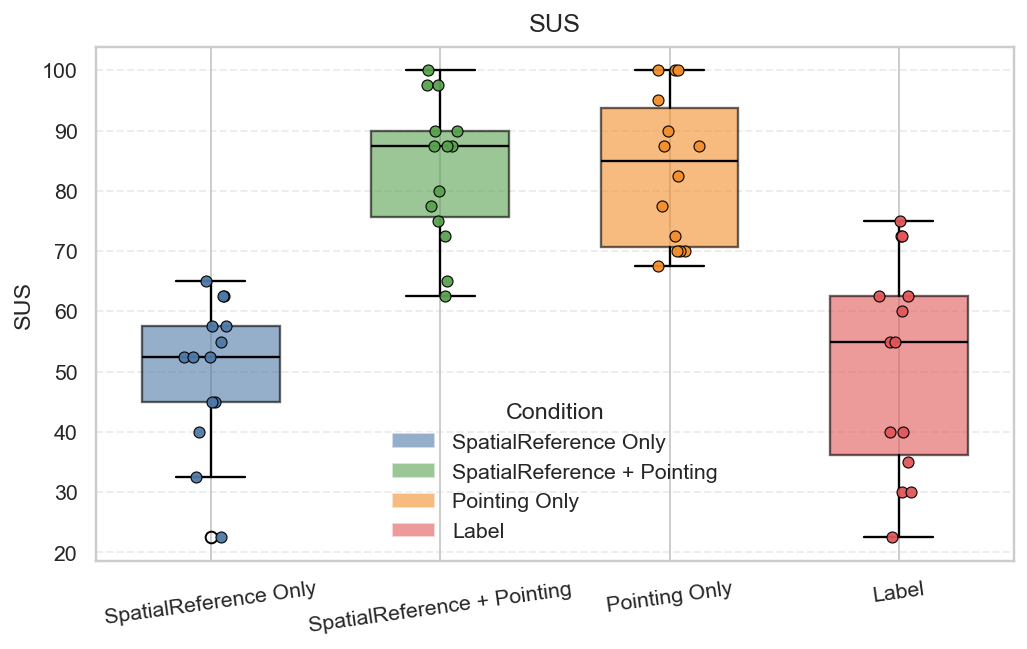

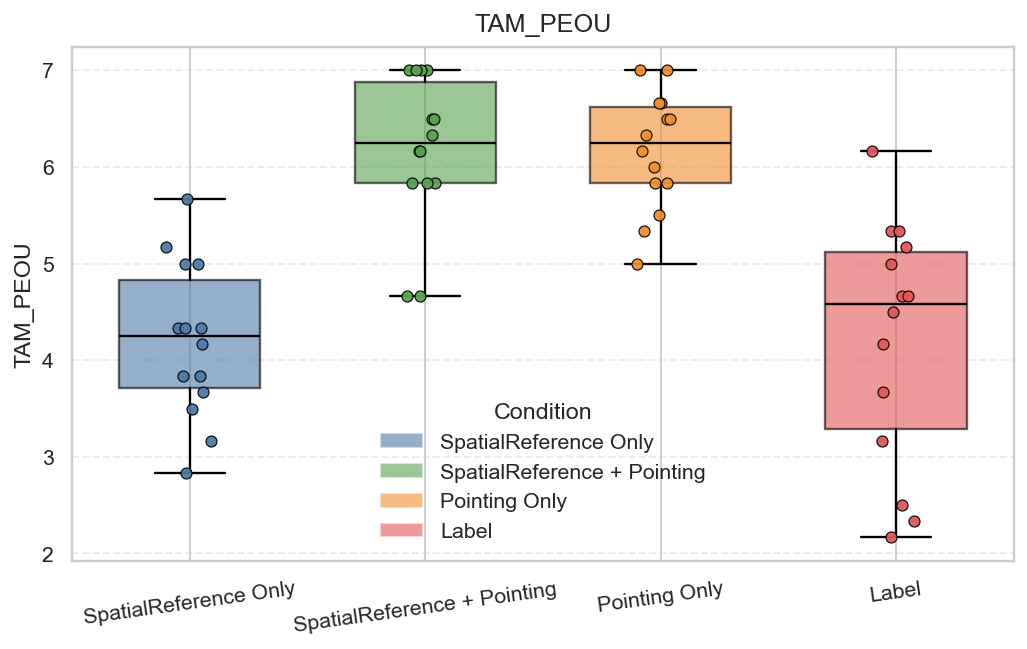

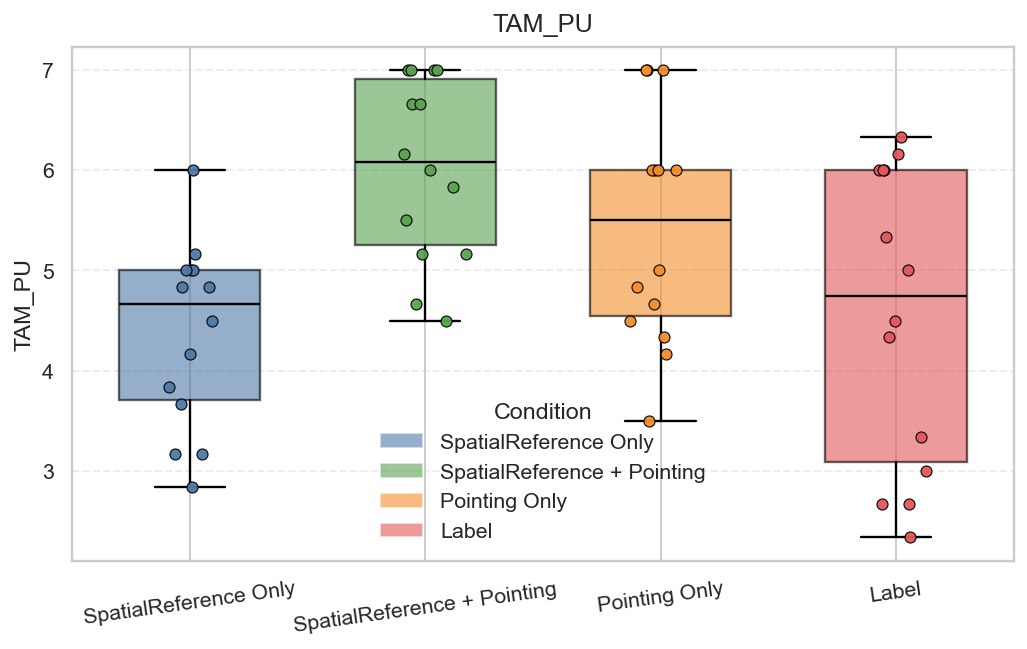

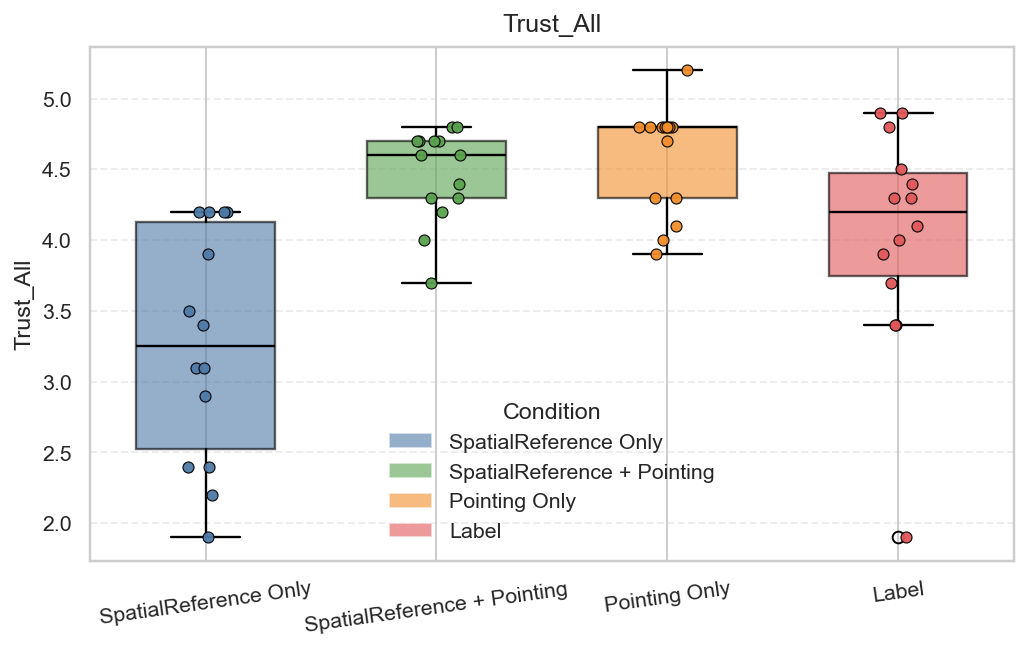

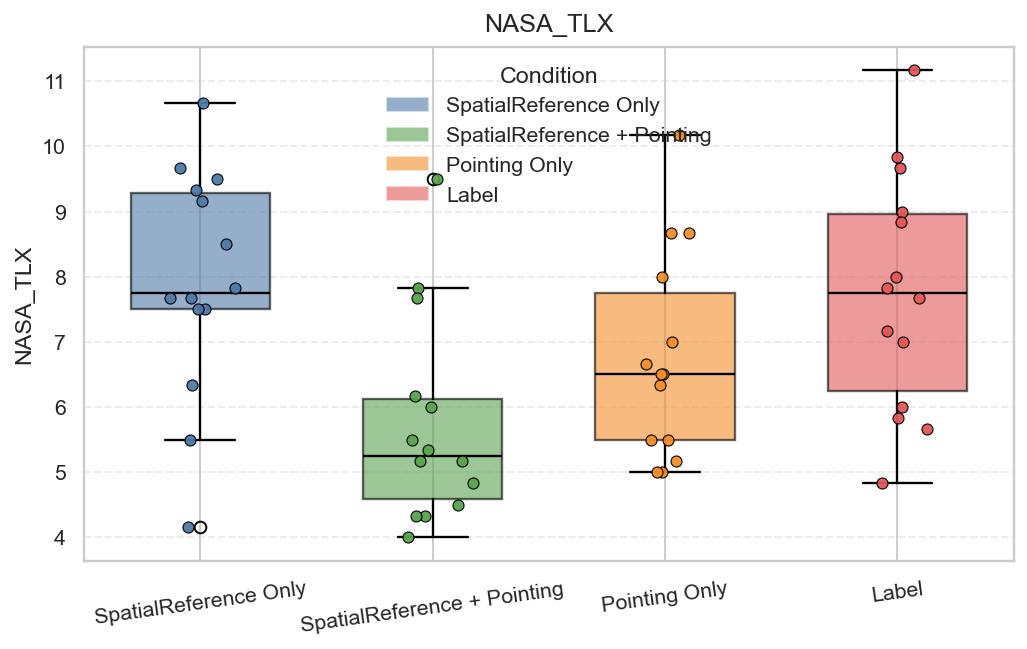

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# === 前提: score_df が既にある ===
metrics = ["SUS", "TAM_PEOU", "TAM_PU", "Trust_All", "NASA_TLX"]

# 条件ラベル & 表示順
cond_labels = {
    1: "SpatialReference Only",
    2: "SpatialReference + Pointing",
    3: "Pointing Only",
    4: "Label",
}
cond_order = [1, 2, 3, 4]

# 条件ごとの色（固定配色）
cond_colors = {
    1: "#4E79A7",  # Blue
    2: "#59A14F",  # Green
    3: "#F28E2B",  # Orange
    4: "#E15759",  # Red
}

# --- 型の整備 ---
df = score_df.copy()
df["Condition"] = pd.to_numeric(df["Condition"], errors="coerce").astype("Int64")
for m in metrics:
    df[m] = pd.to_numeric(df[m], errors="coerce")
df = df.dropna(subset=["Condition"])

present_conds = [c for c in cond_order if c in df["Condition"].unique().tolist()]

# 乱数固定（毎回同じジッターにしたい場合）
rng = np.random.default_rng(42)

# --- 各メトリクスを個別の図として描画（箱＋ドット） ---
for metric in metrics:
    # 条件順にデータを整列
    data = [df.loc[df["Condition"] == c, metric].dropna().values for c in present_conds]

    fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=140)
    bp = ax.boxplot(
        data,
        patch_artist=True,
        labels=[cond_labels[c] for c in present_conds],
        widths=0.6,
        showmeans=False,
        whis=1.5
    )

    # 箱に条件色を適用
    for patch, c in zip(bp["boxes"], present_conds):
        patch.set_facecolor(cond_colors[c])
        patch.set_alpha(0.60)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.2)

    # 線のスタイル
    for k in ["whiskers", "caps", "medians"]:
        for line in bp[k]:
            line.set_color("black")
            line.set_linewidth(1.2)

    # --- 個票（ドット）を重ねる ---
    # 箱ひとつあたりの中心 x は 1,2,3,...
    jitter_scale = 0.06  # 横方向のジッター幅（広げたいときは 0.08~0.12 などに）
    dot_size = 32        # ドットサイズ（大きくしたいときは 40~60 など）
    for xi, c in enumerate(present_conds, start=1):
        ys = df.loc[df["Condition"] == c, metric].dropna().values
        if len(ys) == 0:
            continue
        xs = rng.normal(loc=xi, scale=jitter_scale, size=len(ys))  # 正規ジッター
        ax.scatter(
            xs, ys,
            s=dot_size,
            facecolors=cond_colors[c],
            edgecolors="black",
            linewidths=0.6,
            alpha=0.95,
            zorder=3
        )

    # 軸やグリッド
    ax.set_title(metric, fontsize=13, pad=8)
    ax.set_ylabel(metric)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    plt.xticks(rotation=8)

    # 凡例
    legend_handles = [Patch(facecolor=cond_colors[c], alpha=0.60, label=cond_labels[c]) for c in present_conds]
    ax.legend(handles=legend_handles, title="Condition", frameon=False, loc="best")

    plt.tight_layout()
    plt.show()
